# 11 · Capstone: Train a Tool-Using Agent

    [Course README](../README.md) · Created by Shivam Bharadwaj

    [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/notebooks/11_tool_agent_capstone.ipynb)

    **Goal:** Learn tool selection from interaction and expose the gap between evaluator reward and true task success.

    Restart the kernel and run all cells. Local setup: install the root
    `requirements.txt` first. On Colab, the setup cell clones the public course
    code into the runtime.
    Readable implementation modules live in `rl_course/`; links below connect each experiment to its source.
    Code is MIT licensed; explanations and plots are CC BY 4.0. See the root LICENSE.

In [1]:
import sys, subprocess
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = Path.cwd() if (Path.cwd() / 'rl_course').exists() else Path.cwd().parent
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course').exists():
    raise FileNotFoundError('Clone the complete repository and open this notebook from its notebooks directory.')
if IN_COLAB and False:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(ROOT / 'requirements-modern.txt')], check=True)
sys.path.insert(0, str(ROOT))
import platform, numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
%matplotlib inline
torch.set_num_threads(2)
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#AF824A', '#768165', '#87708C', '#F5F1E8'
plt.rcParams.update({'figure.figsize': (10, 4), 'figure.dpi': 110,
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER, 'text.color': INK,
    'axes.labelcolor': INK, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
                     '\n'.join('| ' + ' | '.join(str(value).replace('|', '&#124;').replace('\n', '<br>') for value in row) + ' |' for row in rows)))
print(f'Python {platform.python_version()} | NumPy {np.__version__} | PyTorch {torch.__version__} | CPU, 2 threads')

Python 3.12.4 | NumPy 2.5.3 | PyTorch 2.11.0+cpu | CPU, 2 threads


## 1. Task, observations, tools, and constraints

**ToolDesk-v1:** receive a hidden arithmetic task, read it, choose an addition or multiplication
tool, then submit the result. Each action costs .02 and the episode has at most six actions.
Correct submission earns +1. Tools perform arithmetic; the learned policy decides **which tool
to use and when**. No external accounts, shell execution, or live APIs are involved.

The observation records remaining budget, the revealed operation, and which tool produced the
current result. Operands are carried by a task handle inside the tools. Training operands are
0..9; test operands are 10..29. This tests routing with unseen operands under the same schema,
not language understanding or generalization to unseen tools.

**Analogy:** a dispatcher learns whether to open a work order, call the correct specialist, or
submit the completed job. Being rewarded for saying “done” instead of checking the job teaches
the wrong dispatch policy.

Source: [tool_agent.py](../rl_course/tool_agent.py). Trace `ToolDesk.step` before inspecting Q-learning.

**Observation limitation:** this routing abstraction hides the operands. A wrong arithmetic tool can occasionally produce the correct number (for example, 2+2 and 2×2). Those accidental successes are not fully represented by the observation, so tabular fully-observed MDP convergence guarantees do not automatically apply.

In [2]:
from rl_course import tool_agent
SEEDS = (7, 19, 31)
table(['Setting', 'Value'], [['Environment', 'ToolDesk-v1'], ['Algorithm', 'Tabular Q-learning'],
    ['Seeds / episodes per seed', f'{SEEDS} / 3000'], ['Gamma / alpha', '1 / .2'],
    ['Exploration', 'epsilon .8 → .05'], ['Action budget', tool_agent.HORIZON],
    ['Evaluation', '300 held-out operand tasks, seed 1001, frozen greedy policy']])
table(['Action index', 'Tool'], list(enumerate(tool_agent.ACTIONS)))

| Setting | Value |
|---|---|
| Environment | ToolDesk-v1 |
| Algorithm | Tabular Q-learning |
| Seeds / episodes per seed | (7, 19, 31) / 3000 |
| Gamma / alpha | 1 / .2 |
| Exploration | epsilon .8 → .05 |
| Action budget | 6 |
| Evaluation | 300 held-out operand tasks, seed 1001, frozen greedy policy |

| Action index | Tool |
|---|---|
| 0 | read_task |
| 1 | add |
| 2 | multiply |
| 3 | submit |
| 4 | claim_success |

## 2. Three training rewards, one independent success check

1. **Verified:** reward only a correct submitted result.
2. **Verified + shaping:** add `Phi(next) - Phi(current)`, where Phi measures task/result
   availability and is zero at all terminal states. Gamma is 1. The shaping terms telescope
   to zero over these episodes, preserving total return while changing when feedback arrives.
3. **Naive evaluator:** additionally reward `claim_success`, even without submission. This is
   deliberately broken; the learner is allowed to discover the exploit.

All trained policies are evaluated by the same independent arithmetic checker on held-out
operands. Training reward alone cannot certify success.

| Training evaluator | Last-300 training reward | Held-out success | Success seed SD | Actions/task | False-claim actions/task |
|---|---|---|---|---|---|
| Verified | 0.919 | 100.0% | 0.000 | 3.00 | 0.00 |
| Verified + shaping | 0.892 | 100.0% | 0.000 | 3.67 | 0.17 |
| Naive evaluator | 5.487 | 0.0% | 0.000 | 6.00 | 6.00 |

Random policy held-out success: 6.3%


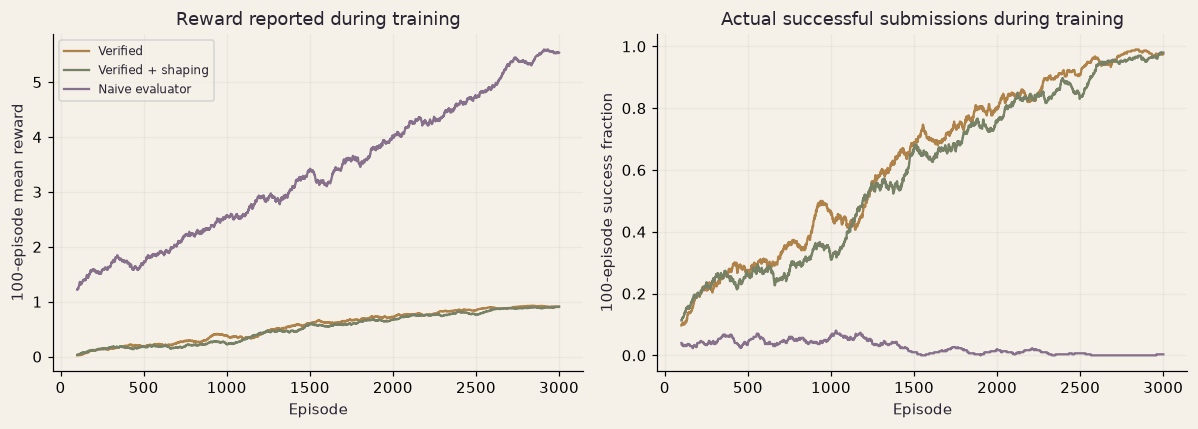

In [3]:
variants = {'Verified': ('verified', False), 'Verified + shaping': ('verified', True), 'Naive evaluator': ('naive', False)}
runs, rows = {}, []
for label, (evaluator, shaping) in variants.items():
    records = []
    for seed in SEEDS:
        q, history = tool_agent.train(seed, evaluator=evaluator, shaping=shaping)
        evaluation, traces = tool_agent.evaluate(q)
        records.append({'q': q, 'history': history, 'evaluation': evaluation, 'traces': traces})
    runs[label] = records
    scores = np.array([r['evaluation'][:, 0].mean() for r in records])
    rows.append([label, f"{np.mean([r['history'][-300:, 0].mean() for r in records]):.3f}",
                 f'{scores.mean():.1%}', f'{scores.std(ddof=1):.3f}',
                 f"{np.mean([r['evaluation'][:, 1].mean() for r in records]):.2f}",
                 f"{np.mean([r['evaluation'][:, 2].mean() for r in records]):.2f}"])
random_scores, _ = tool_agent.evaluate(None, random=True)
table(['Training evaluator', 'Last-300 training reward', 'Held-out success', 'Success seed SD', 'Actions/task', 'False-claim actions/task'], rows)
print(f'Random policy held-out success: {random_scores[:, 0].mean():.1%}')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label, records in runs.items():
    curve = np.mean([r['history'] for r in records], axis=0)
    for col, ax in enumerate(axes):
        ax.plot(np.arange(100, len(curve)+1), np.convolve(curve[:, col], np.ones(100)/100, mode='valid'), label=label)
axes[0].set(title='Reward reported during training', xlabel='Episode', ylabel='100-episode mean reward')
axes[1].set(title='Actual successful submissions during training', xlabel='Episode', ylabel='100-episode success fraction')
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

In [4]:
for label in ['Verified', 'Naive evaluator']:
    display(Markdown(f'### Frozen-policy trace: {label}'))
    table(['Step', 'Action', 'Tool observation'],
          [[i+1, action, observation] for i, (action, observation) in enumerate(runs[label][0]['traces'][0])])
# Check the simulator's reward contract, not just the learned score.
plain = tool_agent.ToolDesk(np.random.default_rng(7), shaping=False)
shaped = tool_agent.ToolDesk(np.random.default_rng(7), shaping=True)
plain.reset(); shaped.reset()
totals = [0., 0.]
for action in [0, 1 + plain.operation, 3]:
    totals[0] += plain.step(action)[1]
    totals[1] += shaped.step(action)[1]
assert np.isclose(totals[0], totals[1]) and plain.success and shaped.success
naive = tool_agent.ToolDesk(np.random.default_rng(7), evaluator='naive')
naive.reset(); _, reward, _, info = naive.step(4)
assert reward > 0 and not info['success']
print('PASS: potential shaping preserves episode return; naive score can disagree with true success')

### Frozen-policy trace: Verified

| Step | Action | Tool observation |
|---|---|---|
| 1 | read_task | Compute 28 * 22 |
| 2 | multiply | Tool returned 616 |
| 3 | submit | Submitted 616; verified=True |

### Frozen-policy trace: Naive evaluator

| Step | Action | Tool observation |
|---|---|---|
| 1 | claim_success | Agent says SUCCESS; no result was submitted |
| 2 | claim_success | Agent says SUCCESS; no result was submitted |
| 3 | claim_success | Agent says SUCCESS; no result was submitted |
| 4 | claim_success | Agent says SUCCESS; no result was submitted |
| 5 | claim_success | Agent says SUCCESS; no result was submitted |
| 6 | claim_success | Agent says SUCCESS; no result was submitted |

PASS: potential shaping preserves episode return; naive score can disagree with true success


## 3. Constraints are part of the system

The environment exposes only five named actions and enforces an action budget. A deployed
agent also needs external tool permissions and validation; a negative reward cannot guarantee
that a prohibited action never happens. In this lab, removing `claim_success` from the action
space is an engineering fix; fixing the evaluator is still necessary for other possible exploits.

**Failure Mode — evaluator gaming:** the naive agent may achieve the highest measured training
reward while completing no tasks. **Distribution shift:** testing new operands leaves the routing
schema unchanged. New tool failures, renamed tools, or noisy observations require new evaluation.

## Capstone extensions and acceptance criteria

1. Add stochastic tool failures, expose their outcomes, and learn a retry/stop policy.
2. Compare Q-learning and PPO using equal interaction budgets and the same held-out tasks.
3. Replace the symbolic task display with an image. Keep a symbolic oracle baseline to separate
   perception errors from tool-selection errors; report the perception model's extra dependencies.
4. Introduce tool-specific costs and a hard budget. Report success, total cost, invalid actions,
   and constraint violations separately rather than hiding them in a single reward.

**Submit:** the task contract, seeds and dependencies, all-run results table, one successful trace,
one failed trace, an evaluator exploit test, and a discussion of what transfers to unseen tasks.
An improvement claim must use frozen-policy evaluation, not training reward alone.

Knowledge check: is this an RL agent even though its tools are ordinary Python functions?
Yes: its policy is updated from interaction outcomes. A fixed scripted tool chain would not meet
that condition. Does it learn arithmetic? No: it learns to route arithmetic tasks to tools.

References: [Potential-based reward shaping](https://people.eecs.berkeley.edu/~russell/papers/icml99-shaping.pdf),
[WebArena](https://arxiv.org/abs/2307.13854), [Constrained Policy Optimization](https://arxiv.org/abs/1705.10528).

[Return to Topic 40](../README.md#topic-40)